# LBF Robust Algorithm Comparison

Compares DeepSRQ with the trained `nfg_transformer_sre` stage-game solver against `sr_adidas` on the same three Level-Based Foraging scenarios used by the EPyMARL baseline notebook. Running all algorithm cells produces 2 algorithms x 3 scenarios = 6 runs.


In [1]:
from pathlib import Path
import sys
import time
import traceback

import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [
    REPO_ROOT,
    REPO_ROOT / "discrete_action_space",
    REPO_ROOT / "discrete_action_space" / "bimatrix_game",
    REPO_ROOT / "discrete_action_space" / "lbf_grid",
]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from bimatrix_game.stats_utils import plot_training_stats, save_training_stats
from discrete_action_space.lbf_grid import pz_wrapper as _lbf_pz_wrapper
from discrete_action_space.lbf_grid import scenarios as _lbf_scenarios

# Some legacy LBF trainers import these notebook-style module names.
sys.modules.setdefault("pz_wrapper", _lbf_pz_wrapper)
sys.modules.setdefault("scenarios", _lbf_scenarios)

from discrete_action_space.dueling_double_dqn_sre import DuelingDoubleDqnSreAgent, DuelingDoubleDqnSreAgentConfig
from discrete_action_space.lbf_grid.deep_srq_lbf import train_lbf_deep_srq_experiment
from discrete_action_space.lbf_grid.epymarl_lbf_env import EPYMARL_LBF_SCENARIOS
from discrete_action_space.lbf_grid.notebook_eval import (
    plot_reward_statistics,
    reward_summary_rows,
    rollout_video_html,
    sample_lbf_rollout,
)
from discrete_action_space.lbf_grid.pz_wrapper import make_pz_env
from discrete_action_space.sr_adidas.train import train_sr_adidas
from discrete_action_space.sre_solvers import make_sre_solver

OUTPUT_ROOT = REPO_ROOT / "discrete_action_space" / "lbf_grid" / "ablation_runs" / "nplayer_solver_ablation"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT


PosixPath('/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/ablation_runs/nplayer_solver_ablation')

In [2]:
# Smoke defaults. Increase N_EPISODES for a full run.
N_EPISODES = 3000
USE_GPU = True
ROBUST_EPSILON_START = 0.5
EPSILON_SCHEDULE = "linear"
BASE_SEED = 2025
NFG_TRANSFORMER_CHECKPOINT = (
    REPO_ROOT
    / "discrete_action_space"
    / "sre_solvers"
    / "nfg_transformer"
    / "nfg_sre_checkpoints"
    / "nfg_sre_lbf3_online.pt"
)
NFG_ACCEPT_GAP = 0.1
EVAL_ROLLOUT_SEED_OFFSET = 50_000
EVAL_VIDEO_FPS = 4


def _epymarl_scenario_to_lbf_config(scenario):
    config = dict(scenario.kwargs)
    config["max_food"] = int(config.pop("max_num_food"))
    config["field_size"] = tuple(config["field_size"])
    return config


SCENARIOS = tuple(
    {
        "key": scenario.key,
        "name": scenario.description,
        "gym_id": scenario.gym_id,
        "time_limit": int(scenario.time_limit),
        "config": _epymarl_scenario_to_lbf_config(scenario),
    }
    for scenario in EPYMARL_LBF_SCENARIOS.values()
)

COMMON_HP = {
    "batch_size": 16,
    "learning_starts": 100,
    "replay_buffer_capacity": 5000,
    "sre_num_repeats": 8,
    "sre_solver_workers": 8,
    "solver_max_iter": 100,
    "solver_tol": 1e-4,
}


SR_ADIDAS_HP = {
    "batch_size": COMMON_HP["batch_size"],
    "learning_starts": COMMON_HP["learning_starts"],
    "buffer_size": COMMON_HP["replay_buffer_capacity"],
    "lr_q": 3e-4,
    "lr_pi": 1e-3,
    "eval_interval": 100,
}


VARIANTS = (
    {
        "label": "nfg_transformer_sre",
        "algorithm": "deep_srq",
        "solver_name": "nfg_transformer_sre",
        "hyperparameter_overrides": {
            "nfg_checkpoint_path": str(NFG_TRANSFORMER_CHECKPOINT),
            "nfg_accept_gap": NFG_ACCEPT_GAP,
            "nfg_fallback_enabled": True,
        },
    },
    {"label": "sr_adidas", "algorithm": "sr_adidas"},
)

print(f"Configured {len(SCENARIOS)} scenarios x {len(VARIANTS)} algorithms = {len(SCENARIOS) * len(VARIANTS)} runs")
print(f"NfgTransformer checkpoint: {NFG_TRANSFORMER_CHECKPOINT}")
print(f"NfgTransformer checkpoint exists: {NFG_TRANSFORMER_CHECKPOINT.exists()}")
for scenario in SCENARIOS:
    print(f"- {scenario['key']}: {scenario['name']}")


Configured 3 scenarios x 2 algorithms = 6 runs
NfgTransformer checkpoint: /home/wowthecoder/SRE-DQN/discrete_action_space/sre_solvers/nfg_transformer/nfg_sre_checkpoints/nfg_sre_lbf3_online.pt
NfgTransformer checkpoint exists: True
- lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes
- lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes
- lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes


In [3]:
TRAINED_AGENTS = {}


def _central_state(obs_dict, agent_order):
    return np.concatenate([np.asarray(obs_dict[a], dtype=np.float32).reshape(-1) for a in agent_order])


class LbfJointEnvWrapper:
    """Small adapter for trainers that expect reset() -> joint_obs and step(list) -> tuple."""

    def __init__(self, env_config, seed=None):
        self.env_config = dict(env_config)
        self.seed = seed
        self.env = make_pz_env(**self.env_config)
        self.agent_order = None
        self.reset_count = 0

    def reset(self):
        seed = None if self.seed is None else int(self.seed) + self.reset_count
        obs_dict, _ = self.env.reset(seed=seed)
        self.reset_count += 1
        self.agent_order = list(self.env.possible_agents)
        return _central_state(obs_dict, self.agent_order)

    def step(self, actions):
        action_dict = {agent: int(actions[i]) for i, agent in enumerate(self.agent_order)}
        obs_dict, reward_dict, term_dict, trunc_dict, info = self.env.step(action_dict)
        next_obs = _central_state(obs_dict, self.agent_order)
        rewards = [float(reward_dict.get(agent, 0.0)) for agent in self.agent_order]
        done = all(
            bool(term_dict.get(agent, False)) or bool(trunc_dict.get(agent, False))
            for agent in self.agent_order
        )
        return next_obs, rewards, done, info

    def close(self):
        self.env.close()



def _probe_lbf(env_config, seed=BASE_SEED):
    env = make_pz_env(**env_config)
    obs_dict, _ = env.reset(seed=seed)
    agent_order = list(env.possible_agents)
    obs_dim = int(_central_state(obs_dict, agent_order).shape[0])
    num_agents = len(agent_order)
    num_actions = int(env.action_space(agent_order[0]).n)
    env.close()
    return obs_dim, num_agents, num_actions


def _joint_rewards(stats):
    rewards = np.asarray(stats.get("rewards", []), dtype=float)
    if rewards.size == 0:
        return np.asarray([], dtype=float)
    return np.sum(rewards, axis=0)


def _wall_clock_seconds(stats):
    timing = stats.get("timing", {})
    return timing.get("wall_clock_seconds", stats.get("wall_clock_seconds", stats.get("wall_seconds")))


def _sre_timing(stats):
    timing = stats.get("timing", {})
    if "sre_solve_time" in timing:
        return timing["sre_solve_time"]
    return stats.get("sre_timing", {})


def _run_key(scenario, variant):
    return f"{scenario['key']}__{variant['label']}"


def _scenario_output_root(scenario, variant):
    return OUTPUT_ROOT / scenario["key"] / variant["label"]


def _stamp_scenario_metadata(stats, *, scenario, variant, seed):
    stats["scenario_key"] = scenario["key"]
    stats["scenario_name"] = scenario["name"]
    stats["gym_id"] = scenario["gym_id"]
    stats["time_limit"] = int(scenario["time_limit"])
    stats["lbf_config"] = dict(scenario["config"])
    stats["ablation_variant"] = variant["label"]
    stats["run_key"] = _run_key(scenario, variant)
    stats["seed"] = int(seed)
    return stats


def _write_stats_artifacts(stats):
    run_dir = Path(stats["artifact_dir"])
    run_dir.mkdir(parents=True, exist_ok=True)
    stats_path = Path(stats.get("stats_path", run_dir / "training_stats.txt"))
    plot_path = run_dir / "training_plot.png"
    plot_training_stats(stats, out_path=plot_path)
    stats["plot_path"] = str(plot_path)
    stats["stats_path"] = str(stats_path)
    save_training_stats(stats_path, stats)
    return stats


def _failure_stats(*, scenario, variant, seed, exc):
    run_dir = _scenario_output_root(scenario, variant)
    run_dir.mkdir(parents=True, exist_ok=True)
    stats = {
        "environment": "lbf_grid",
        "algorithm": variant["algorithm"],
        "status": "failed",
        "error_type": type(exc).__name__,
        "error_message": str(exc),
        "traceback": traceback.format_exc(),
        "rewards": [],
        "n_episodes": 0,
        "artifact_dir": str(run_dir),
        "stats_path": str(run_dir / "training_stats.txt"),
    }
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    save_training_stats(stats["stats_path"], stats)
    return stats


def _normalize_sr_adidas_stats(raw, *, variant, scenario, seed, env_config, obs_dim, num_agents, num_actions, run_dir, elapsed):
    stats = {
        "environment": "lbf_grid",
        "algorithm": "sr_adidas",
        "rewards": np.asarray(raw["episode_rewards"], dtype=float).T.tolist(),
        "n_episodes": len(raw["episode_rewards"]),
        "epsilon_robust_initial": ROBUST_EPSILON_START,
        "epsilon_schedule": EPSILON_SCHEDULE,
        "lbf_config": env_config,
        "num_agents": int(num_agents),
        "num_actions": int(num_actions),
        "obs_dim": int(obs_dim),
        "agent_labels": [f"Agent {i + 1} (SR-ADIDAS)" for i in range(num_agents)],
        "artifact_dir": str(run_dir),
        "wall_clock_seconds": float(elapsed),
        "train_losses_q": raw.get("train_losses_q", []),
        "train_losses_pi": raw.get("train_losses_pi", []),
        "adi_estimates": raw.get("adi_estimates", []),
    }
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    return _write_stats_artifacts(stats)


def run_deep_srq_variant(variant, scenario, seed):
    solver_name = variant["solver_name"]
    hp = dict(COMMON_HP)
    hp.update(variant.get("hyperparameter_overrides", {}))
    checkpoint_path = hp.get("nfg_checkpoint_path")
    if solver_name in {"nfg_transformer_sre", "nfg_sre"} and checkpoint_path and not Path(checkpoint_path).exists():
        raise FileNotFoundError(f"NfgTransformer checkpoint not found: {checkpoint_path}")
    stats = train_lbf_deep_srq_experiment(
        n_episodes=N_EPISODES,
        solver_name=solver_name,
        epsilon_robust_initial=ROBUST_EPSILON_START,
        epsilon_schedule=EPSILON_SCHEDULE,
        seed=seed,
        output_root=_scenario_output_root(scenario, variant),
        lbf_config_overrides=scenario["config"],
        hyperparameter_overrides=hp,
        use_gpu=USE_GPU,
        write_plots=False,
        run_name_suffix=_run_key(scenario, variant),
        print_full_stats=False,
    )
    stats["algorithm"] = "deep_srq"
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    return _write_stats_artifacts(stats)

def run_sr_adidas_variant(variant, scenario, seed):
    env_config = dict(scenario["config"])
    obs_dim, num_agents, num_actions = _probe_lbf(env_config, seed)
    run_dir = _scenario_output_root(scenario, variant)
    run_dir.mkdir(parents=True, exist_ok=True)

    def env_factory():
        return LbfJointEnvWrapper(env_config, seed=seed)

    start = time.perf_counter()
    raw = train_sr_adidas(
        env_factory=env_factory,
        obs_dim=obs_dim,
        num_agents=num_agents,
        num_actions=num_actions,
        n_episodes=N_EPISODES,
        max_steps_per_episode=int(env_config["max_episode_steps"]),
        seed=seed,
        epsilon_robust=ROBUST_EPSILON_START,
        epsilon_robust_end=0.0 if EPSILON_SCHEDULE == "linear" else ROBUST_EPSILON_START,
        use_gpu=USE_GPU,
        verbose=True,
        **SR_ADIDAS_HP,
    )
    elapsed = time.perf_counter() - start
    trained_agent = raw.get("agent")
    if trained_agent is not None:
        TRAINED_AGENTS[_run_key(scenario, variant)] = trained_agent
    return _normalize_sr_adidas_stats(
        raw,
        variant=variant,
        scenario=scenario,
        seed=seed,
        env_config=env_config,
        obs_dim=obs_dim,
        num_agents=num_agents,
        num_actions=num_actions,
        run_dir=run_dir,
        elapsed=elapsed,
    )




def _make_deep_srq_eval_solver(stats):
    solver_name = stats.get("solver_name", "path_mcp_nplayer")
    hp = dict(stats.get("hyperparameters", {}))
    seed = int(stats.get("seed", BASE_SEED))
    if solver_name in {"nfg_transformer_sre", "nfg_sre"}:
        return make_sre_solver(
            solver_name,
            random_seed=seed,
            checkpoint_path=hp.get("nfg_checkpoint_path"),
            device=hp.get("nfg_device"),
            fallback_enabled=hp.get("nfg_fallback_enabled", True),
            accept_exploitability_tol=hp.get("nfg_accept_gap"),
        )
    return make_sre_solver(
        solver_name,
        random_seed=seed,
        max_workers=hp.get("sre_solver_workers", 8),
    )


def _load_deep_srq_eval_agent(stats):
    run_dir = Path(stats["artifact_dir"])
    checkpoint_path = run_dir / "shared_deepsrq_best.pt"
    if not checkpoint_path.exists():
        checkpoint_path = run_dir / "shared_deepsrq_final.pt"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"No DeepSRQ checkpoint found in {run_dir}")

    hp = dict(stats.get("hyperparameters", {}))
    agent = DuelingDoubleDqnSreAgent(
        DuelingDoubleDqnSreAgentConfig(
            agent_id=0,
            obs_dim=int(stats["obs_dim"]),
            num_agents=int(stats["num_agents"]),
            num_actions=int(stats["num_actions"]),
            epsilon_robust=float(stats.get("epsilon_robust_initial", ROBUST_EPSILON_START)),
            epsilon_explore=0.0,
            lr=hp.get("learning_rate", 3e-4),
            gamma=hp.get("gamma", 0.99),
            buffer_size=hp.get("replay_buffer_capacity", 5000),
            learning_starts=hp.get("learning_starts", 100),
            grad_clip_norm=hp.get("grad_clip_max_norm", 10.0),
            sre_num_repeats=hp.get("sre_num_repeats", 8),
            sre_include_pure_starts=hp.get("sre_include_pure_starts", True),
            train_every=hp.get("train_every", 4),
            network_type=hp.get("network_type", "shared_trunk_separate_heads"),
            q_hidden_dims=tuple(hp.get("q_hidden_dims", (128, 128))),
            use_gpu=USE_GPU,
            sre_solver=_make_deep_srq_eval_solver(stats),
            target_equilibrium_update_steps=hp.get("target_equilibrium_update_steps", 4),
            sre_policy_cache_enabled=hp.get("sre_policy_cache_enabled", True),
            sre_policy_cache_size=hp.get("sre_policy_cache_size", 4096),
            sre_policy_cache_round_digits=hp.get("sre_policy_cache_round_digits", 6),
            sre_state_cache_round_digits=hp.get("sre_state_cache_round_digits", 4),
            sre_approx_cache_enabled=hp.get("sre_approx_cache_enabled", True),
            sre_cache_exploitability_tol=hp.get("sre_cache_exploitability_tol", 1e-3),
            sre_solver_exploitability_tol=hp.get("sre_solver_exploitability_tol", 1e-4),
            sre_solver_early_exit=hp.get("sre_solver_early_exit", True),
        )
    )
    map_location = None if USE_GPU and torch.cuda.is_available() else "cpu"
    agent.load_checkpoint(checkpoint_path, map_location=map_location)
    agent.config.epsilon_explore = 0.0
    return agent


def evaluate_training_run(stats):
    if stats.get("status") in {"failed", "skipped"}:
        print(f"Skipping rollout for {stats.get('run_key')}: {stats.get('error_message') or stats.get('skip_reason')}")
        return None

    algorithm = stats.get("algorithm")
    run_key = stats.get("run_key", stats.get("ablation_variant", algorithm))
    env_config = dict(stats["lbf_config"])
    seed = int(stats.get("seed", BASE_SEED)) + EVAL_ROLLOUT_SEED_OFFSET
    max_steps = int(stats.get("time_limit", env_config.get("max_episode_steps", 75)))

    if algorithm == "deep_srq":
        eval_agent = _load_deep_srq_eval_agent(stats)

        def policy_fn(**kwargs):
            return eval_agent.act_joint(kwargs["state"])

    elif algorithm == "sr_adidas":
        eval_agent = TRAINED_AGENTS.get(run_key)
        if eval_agent is None:
            print(f"No in-memory SR-ADIDAS agent for {run_key}; rerun its training cell before rollout playback.")
            return None
        old_eps = (
            eval_agent.action_eps_schedule.start,
            eval_agent.action_eps_schedule.end,
        )
        eval_agent.action_eps_schedule.start = 0.0
        eval_agent.action_eps_schedule.end = 0.0

        def policy_fn(**kwargs):
            return eval_agent.act_all(kwargs["state"])

    else:
        print(f"No rollout policy registered for algorithm={algorithm!r}")
        return None

    try:
        rollout = sample_lbf_rollout(
            make_env=lambda: make_pz_env(**env_config, render_mode="rgb_array"),
            policy_fn=policy_fn,
            seed=seed,
            max_steps=max_steps,
        )
        print(
            f"{run_key} eval rollout | steps={rollout['steps']} | "
            f"joint_reward={rollout['joint_reward']:.4f} | per_agent={rollout['total_rewards']}"
        )
        try:
            display(rollout_video_html(
                rollout["frames"],
                fps=EVAL_VIDEO_FPS,
                title=f"{run_key} evaluation rollout",
            ))
        except Exception as exc:
            print(f"Rollout video unavailable for {run_key}: {type(exc).__name__}: {exc}")
        return rollout
    finally:
        if algorithm == "deep_srq" and eval_agent is not None:
            eval_agent.close()
        if algorithm == "sr_adidas" and eval_agent is not None:
            eval_agent.action_eps_schedule.start, eval_agent.action_eps_schedule.end = old_eps


def evaluate_algorithm_runs(stats_by_scenario):
    rollouts = {}
    for scenario_key, stats in stats_by_scenario.items():
        rollouts[scenario_key] = evaluate_training_run(stats)
    fig = plot_reward_statistics(
        stats_by_scenario.values(),
        title=f"{next(iter(stats_by_scenario.values())).get('ablation_variant', 'algorithm')} reward statistics",
        tail=min(100, N_EPISODES),
    )
    if fig is not None:
        display(fig)
    return rollouts


RUNNERS = {
    "deep_srq": run_deep_srq_variant,
    "sr_adidas": run_sr_adidas_variant,
}


In [4]:
results = {}


def run_variant_on_scenario(label, scenario_key):
    variant = next(item for item in VARIANTS if item["label"] == label)
    scenario = next(item for item in SCENARIOS if item["key"] == scenario_key)
    variant_idx = list(VARIANTS).index(variant)
    scenario_idx = list(SCENARIOS).index(scenario)
    seed = BASE_SEED + scenario_idx * len(VARIANTS) + variant_idx
    key = _run_key(scenario, variant)
    print()
    print(f"=== Running {key} ===")
    try:
        stats = RUNNERS[variant["algorithm"]](variant, scenario, seed)
    except Exception as exc:
        stats = _failure_stats(scenario=scenario, variant=variant, seed=seed, exc=exc)
        print(f"FAILED {key}: {type(exc).__name__}: {exc}")
    results[key] = stats
    if stats.get("status") == "skipped":
        print(f"Skipped {key}: {stats['skip_reason']}")
    save_training_stats(OUTPUT_ROOT / "manifest.txt", results)
    return stats


def run_algorithm(label):
    return {
        scenario["key"]: run_variant_on_scenario(label, scenario["key"])
        for scenario in SCENARIOS
    }


def run_all_ablation():
    for variant in VARIANTS:
        run_algorithm(variant["label"])
    return results



=== Running lbf_8x8_2p_2f_levels12__nfg_transformer_sre ===
LBF DeepSRQ | players=2 | solver=nfg_transformer_sre | eps0=0.5 | schedule=linear | seed=2025


lbf:nfg_transformer_sre_eps0.5_linear__lbf_8x8_2p_2f_levels12__nfg_transformer_sre: 100%|█| 3000/3000 [1:13:17<00:00,  1



Reward Summary
Scenario           | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
-------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
LBF 3-player basic | DeepSRQ self-play | Agent 1 (DeepSRQ) | 0.03 | 0.10 | 0.02             | 0.08            | 3000    
LBF 3-player basic | DeepSRQ self-play | Agent 2 (DeepSRQ) | 0.09 | 0.20 | 0.07             | 0.17            | 3000    


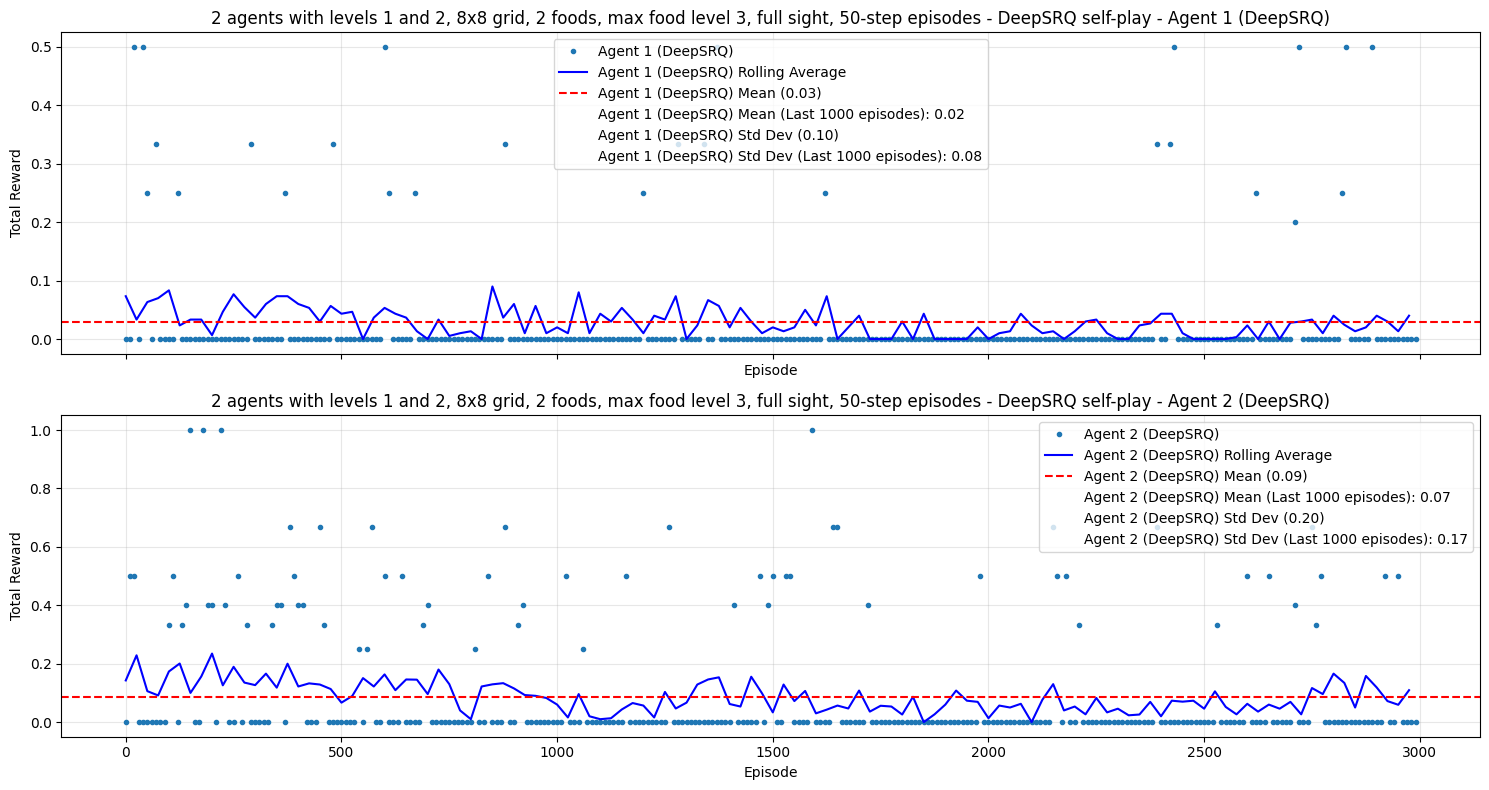


=== Running lbf_8x8_2p_2f_force_coop__nfg_transformer_sre ===
LBF DeepSRQ | players=2 | solver=nfg_transformer_sre | eps0=0.5 | schedule=linear | seed=2027


lbf:nfg_transformer_sre_eps0.5_linear__lbf_8x8_2p_2f_force_coop__nfg_transformer_sre:   5%| | 143/3000 [01:45<35:05,  1.


KeyboardInterrupt: 

In [5]:
nfg_transformer_sre_stats = run_algorithm("nfg_transformer_sre")
nfg_transformer_sre_rollouts = evaluate_algorithm_runs(nfg_transformer_sre_stats)



=== Running lbf_8x8_2p_2f_levels12__sr_adidas ===


SR-ADIDAS:   3%|██▎                                                                  | 101/3000 [00:24<10:07,  4.77it/s]

[ep   100] mean_sum_reward=   0.08 | tau=0.0010 | eps_rob=0.479 | eps_exp=0.947 | adi=0.00099 | buf=5000


SR-ADIDAS:   7%|████▌                                                                | 200/3000 [00:48<12:50,  3.64it/s]

[ep   200] mean_sum_reward=   0.04 | tau=0.0010 | eps_rob=0.458 | eps_exp=0.894 | adi=0.00900 | buf=5000


...

[ep  2800] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00228 | buf=5000


SR-ADIDAS:  97%|█████████████████████████████████████████████████████████████████▊  | 2901/3000 [11:47<00:19,  5.05it/s]

[ep  2900] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00160 | buf=5000


SR-ADIDAS: 100%|████████████████████████████████████████████████████████████████████| 3000/3000 [12:06<00:00,  4.13it/s]


[ep  3000] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00116 | buf=5000


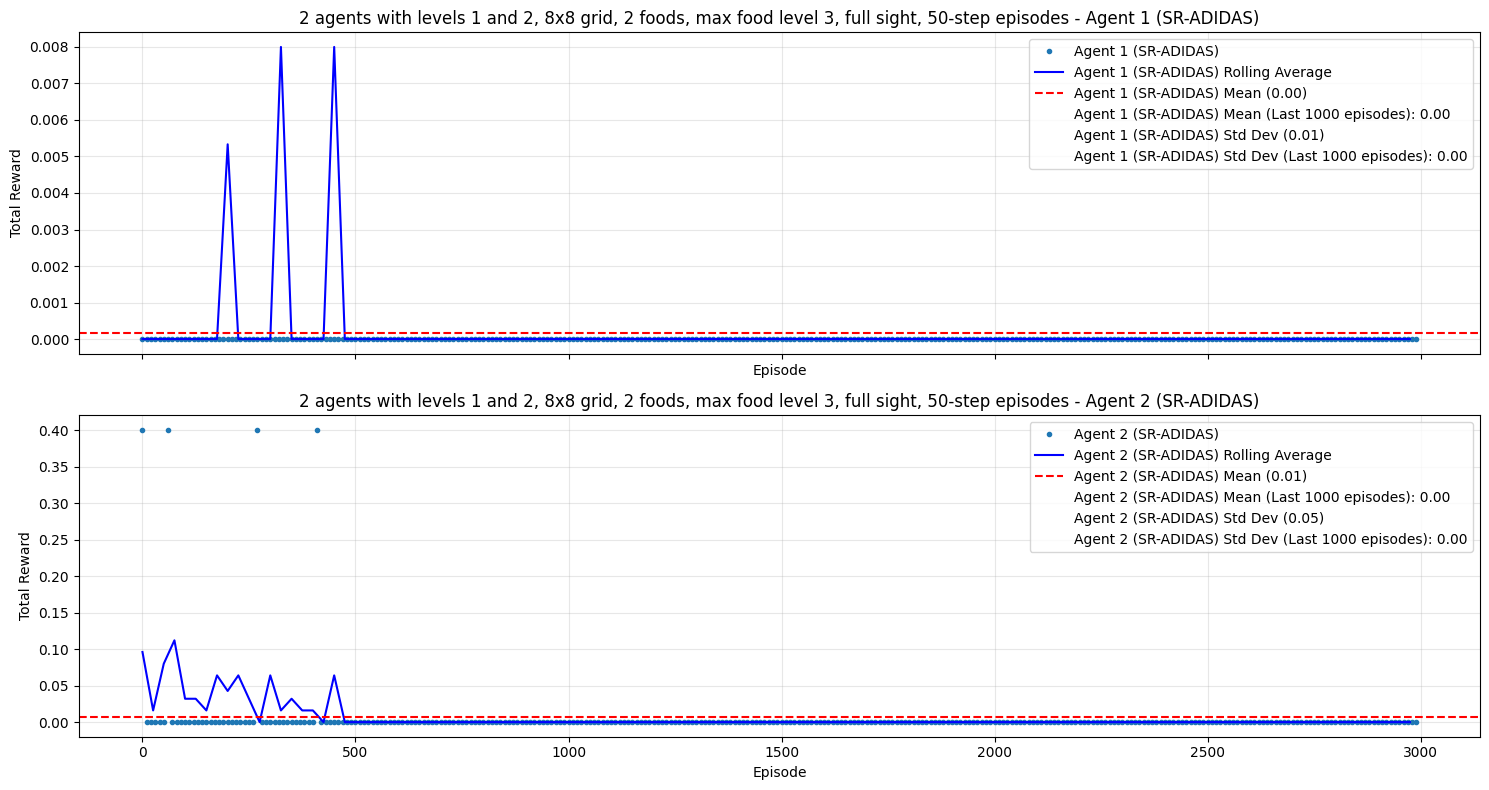


=== Running lbf_8x8_2p_2f_force_coop__sr_adidas ===


SR-ADIDAS:   3%|██▎                                                                  | 100/3000 [00:25<11:40,  4.14it/s]

[ep   100] mean_sum_reward=   0.00 | tau=0.0122 | eps_rob=0.479 | eps_exp=0.947 | adi=0.00215 | buf=5000


SR-ADIDAS:   7%|████▌                                                                | 200/3000 [00:47<10:34,  4.41it/s]

[ep   200] mean_sum_reward=   0.00 | tau=0.0061 | eps_rob=0.458 | eps_exp=0.894 | adi=0.00380 | buf=5000


...

[ep  2800] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00002 | buf=5000


SR-ADIDAS:  97%|█████████████████████████████████████████████████████████████████▊  | 2901/3000 [11:52<00:19,  5.09it/s]

[ep  2900] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00001 | buf=5000


SR-ADIDAS: 100%|████████████████████████████████████████████████████████████████████| 3000/3000 [12:12<00:00,  4.10it/s]


[ep  3000] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00001 | buf=5000


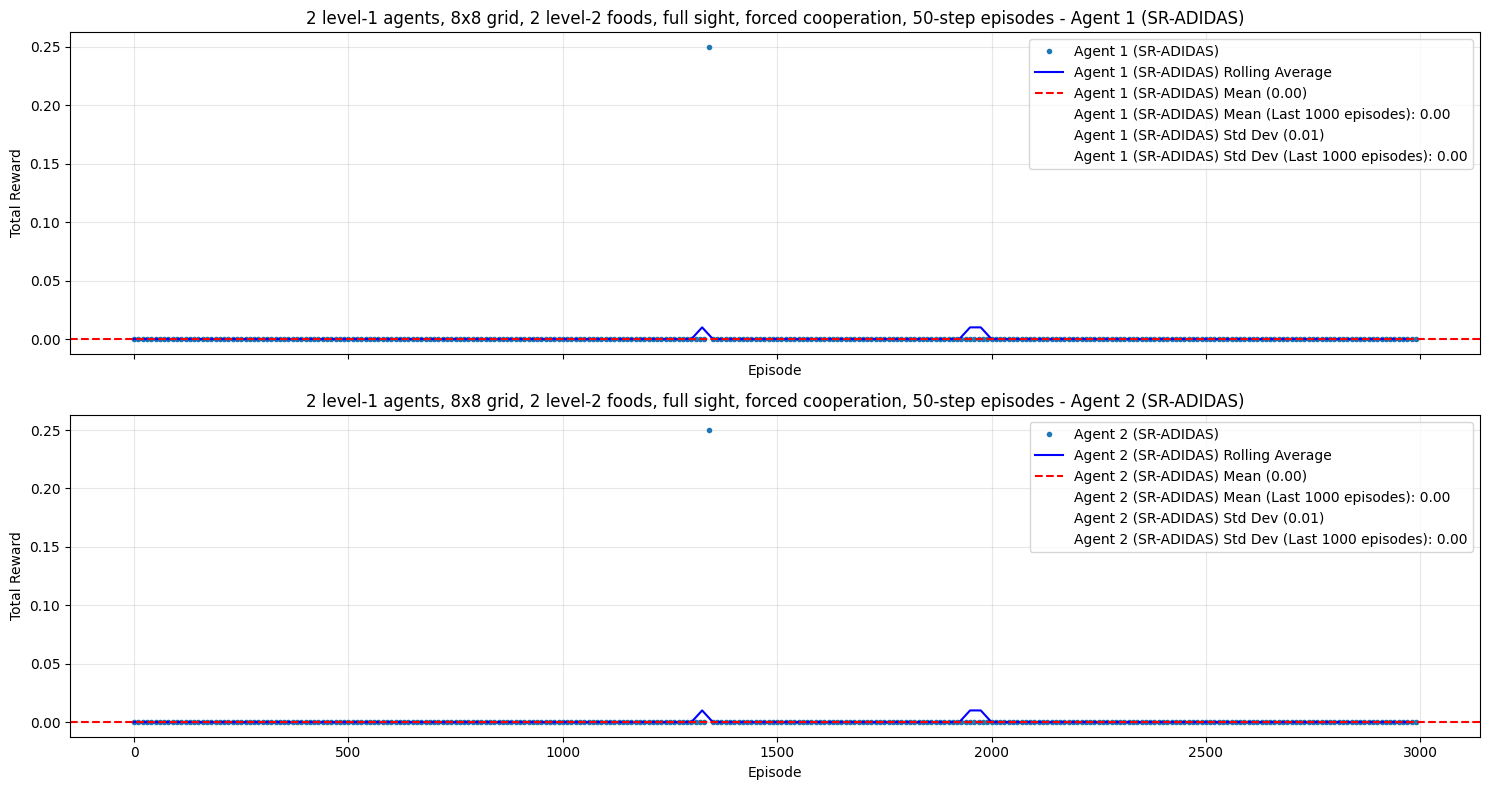


=== Running lbf_10x10_3p_8f_levels123__sr_adidas ===


SR-ADIDAS:   3%|██▎                                                                  | 100/3000 [01:17<34:39,  1.39it/s]

[ep   100] mean_sum_reward=   0.24 | tau=0.0061 | eps_rob=0.479 | eps_exp=0.947 | adi=0.00749 | buf=5000


SR-ADIDAS:   7%|████▌                                                                | 200/3000 [02:37<33:42,  1.38it/s]

[ep   200] mean_sum_reward=   0.25 | tau=0.0031 | eps_rob=0.458 | eps_exp=0.894 | adi=0.00492 | buf=5000


...

[ep  2800] mean_sum_reward=   0.37 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00030 | buf=5000


SR-ADIDAS:  97%|█████████████████████████████████████████████████████████████████▋  | 2900/3000 [35:46<00:54,  1.84it/s]

[ep  2900] mean_sum_reward=   0.38 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00032 | buf=5000


SR-ADIDAS: 100%|████████████████████████████████████████████████████████████████████| 3000/3000 [36:41<00:00,  1.36it/s]


[ep  3000] mean_sum_reward=   0.39 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00023 | buf=5000


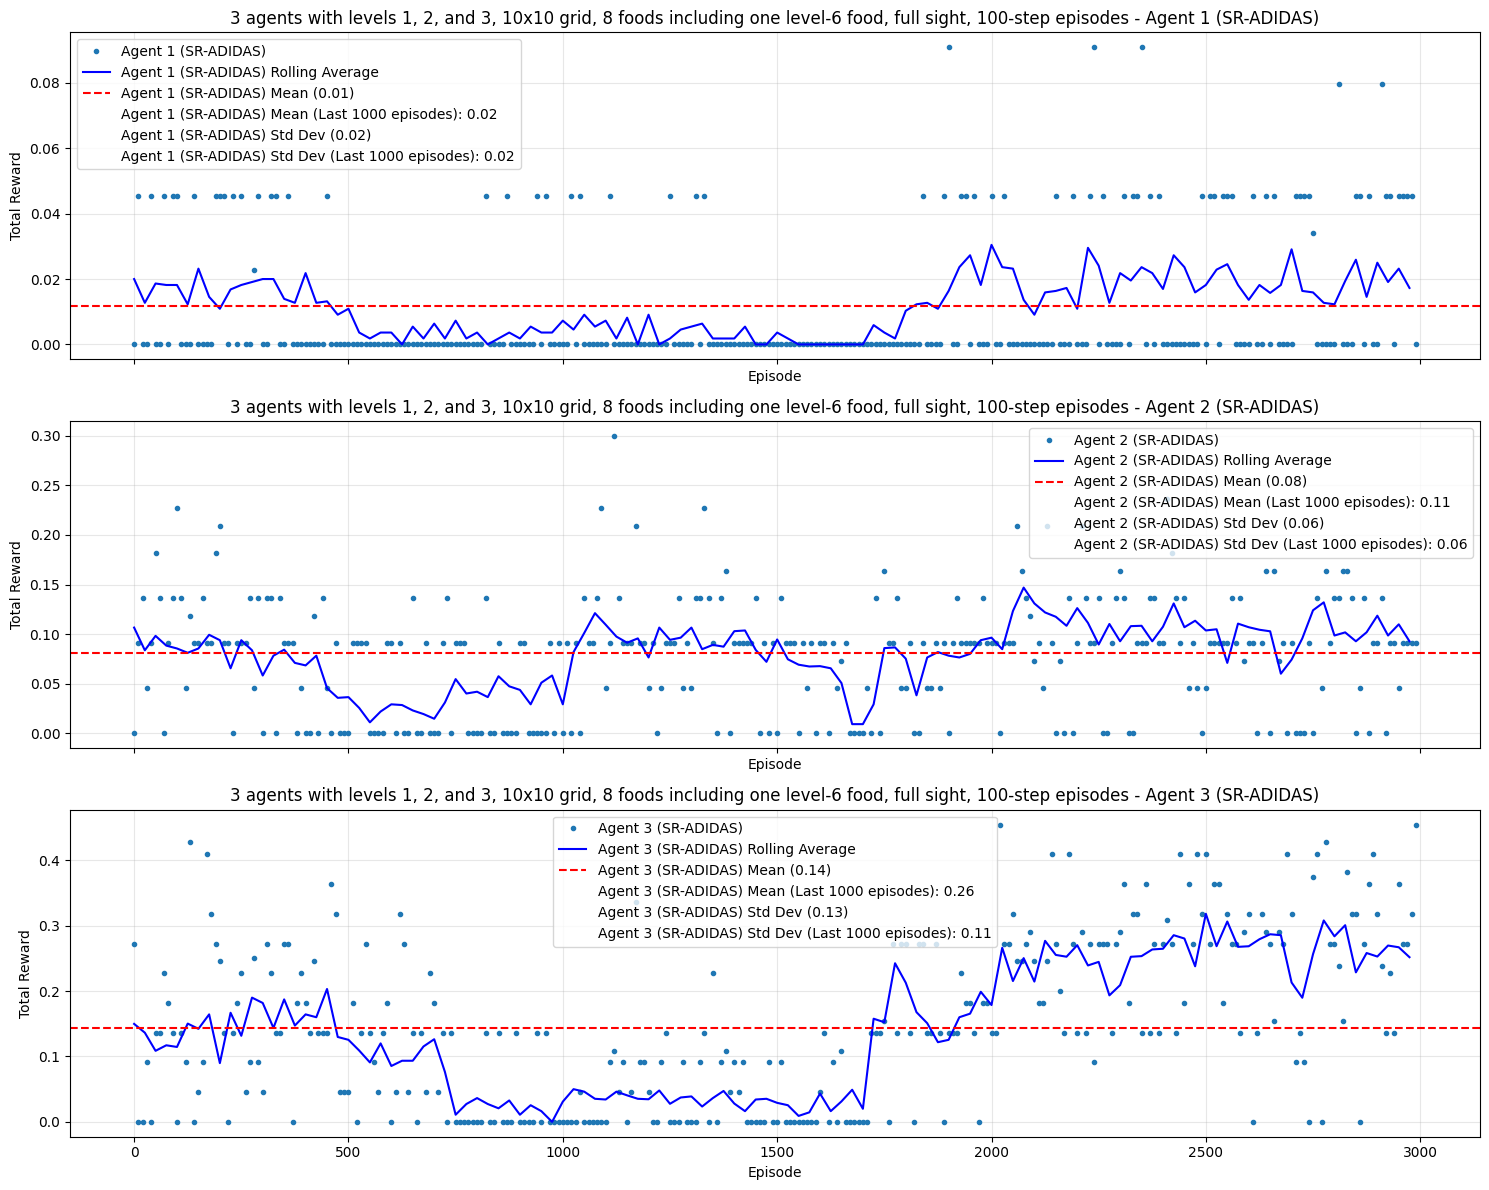

In [6]:
sr_adidas_stats = run_algorithm("sr_adidas")
sr_adidas_rollouts = evaluate_algorithm_runs(sr_adidas_stats)


In [7]:
sorted(results.keys())


['lbf_10x10_3p_8f_levels123__sr_adidas',
 'lbf_8x8_2p_2f_force_coop__sr_adidas',
 'lbf_8x8_2p_2f_levels12__nfg_transformer_sre',
 'lbf_8x8_2p_2f_levels12__sr_adidas']

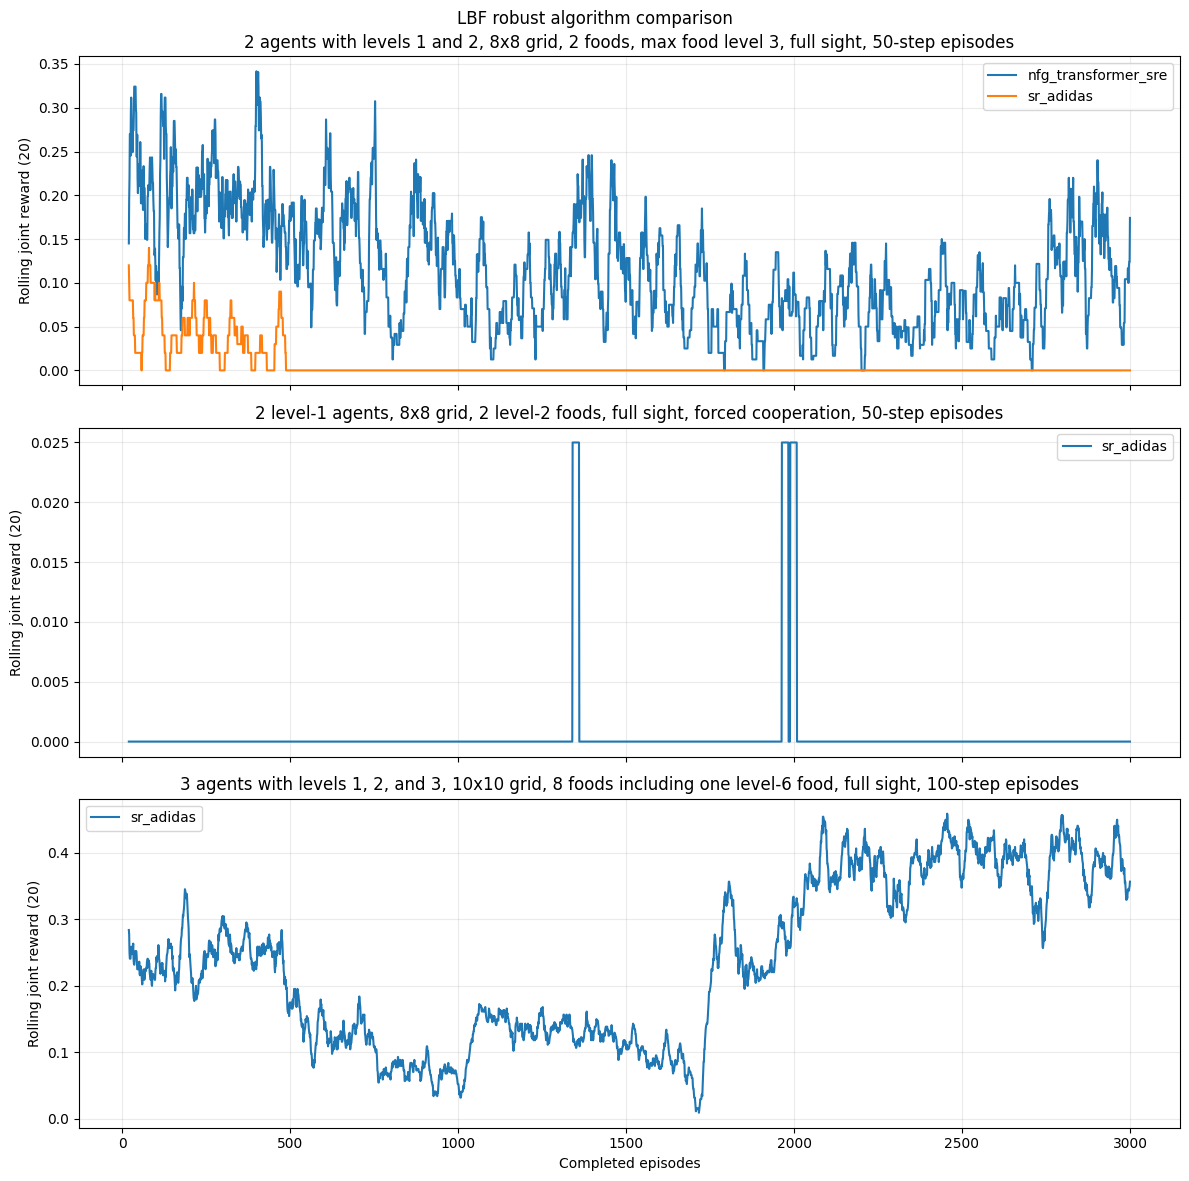

In [8]:
import matplotlib.pyplot as plt


def rolling(values, window=20):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(window, values.size))
    return np.convolve(values, np.ones(window) / window, mode="valid")


ROLLING_WINDOW = 20
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(12, 4 * len(SCENARIOS)), sharex=True)
if len(SCENARIOS) == 1:
    axes = [axes]

for ax, scenario in zip(axes, SCENARIOS):
    for variant in VARIANTS:
        key = _run_key(scenario, variant)
        stats = results.get(key)
        if not stats:
            continue
        joint_rewards = _joint_rewards(stats)
        if joint_rewards.size == 0:
            continue
        smoothed = rolling(joint_rewards, window=ROLLING_WINDOW)
        x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_rewards.size)
        ax.plot(x, smoothed, label=variant["label"])
    ax.set_title(scenario["name"])
    ax.set_ylabel(f"Rolling joint reward ({ROLLING_WINDOW})")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Completed episodes")
fig.suptitle("LBF robust algorithm comparison")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "reward_curves.png")


In [9]:
rows = []
for key, stats in sorted(results.items()):
    joint_rewards = _joint_rewards(stats)
    sre_timing = _sre_timing(stats)
    row = {
        "run_key": key,
        "scenario_key": stats.get("scenario_key"),
        "scenario_name": stats.get("scenario_name"),
        "variant": stats.get("ablation_variant"),
        "algorithm": stats.get("algorithm"),
        "status": stats.get("status", "ok"),
        "episodes": int(stats.get("n_episodes", joint_rewards.size)),
        "mean_joint_reward": None if joint_rewards.size == 0 else float(np.mean(joint_rewards)),
        "mean_last_20_joint_reward": None if joint_rewards.size == 0 else float(np.mean(joint_rewards[-20:])),
        "wall_clock_seconds": _wall_clock_seconds(stats),
        "sre_solves": sre_timing.get("count"),
        "mean_sre_solve_ms": None if sre_timing.get("mean_seconds") is None else 1000 * sre_timing["mean_seconds"],
        "stats_path": stats.get("stats_path"),
        "error_message": stats.get("error_message"),
        "skip_reason": stats.get("skip_reason"),
    }
    rows.append(row)
rows


[{'run_key': 'lbf_10x10_3p_8f_levels123__sr_adidas',
  'scenario_key': 'lbf_10x10_3p_8f_levels123',
  'scenario_name': '3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes',
  'variant': 'sr_adidas',
  'algorithm': 'sr_adidas',
  'status': 'ok',
  'episodes': 3000,
  'mean_joint_reward': 0.23639394587899248,
  'mean_last_20_joint_reward': 0.35681819207966325,
  'wall_clock_seconds': 2125.840782601008,
  'sre_solves': None,
  'mean_sre_solve_ms': None,
  'stats_path': '/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/ablation_runs/nplayer_solver_ablation/lbf_10x10_3p_8f_levels123/sr_adidas/training_stats.txt',
  'error_message': None,
  'skip_reason': None},
 {'run_key': 'lbf_8x8_2p_2f_force_coop__sr_adidas',
  'scenario_key': 'lbf_8x8_2p_2f_force_coop',
  'scenario_name': '2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes',
  'variant': 'sr_adidas',
  'algorithm': 'sr_adidas'

In [ ]:
fig = plot_reward_statistics(
    results.values(),
    title="LBF robust algorithm reward statistics across all completed runs",
    tail=min(100, N_EPISODES),
)
if fig is not None:
    display(fig)
reward_summary_rows(results.values(), tail=min(100, N_EPISODES))
